# Quantile Forecasting of Closing Price

## Project Objective

This notebook focuses on **quantile forecasting of closing price** in a financial time series setting.  
Unlike traditional point forecasting, which predicts a single expected value, quantile forecasting estimates multiple conditional quantiles of the target variable. This allows us to capture uncertainty in predictions and produce a more informative forecast range.

In this notebook, we will:

- inspect and preprocess the dataset
- perform exploratory data analysis
- engineer time series features
- train quantile forecasting models
- evaluate forecast performance using quantile-specific metrics
- visualize forecast bands and compare model behavior

---

## Why Quantile Forecasting?

Financial time series are often volatile and uncertain. Predicting only one value may hide important risk information.  
Quantile forecasting helps estimate:

- a **lower bound** of the likely future price
- a **median forecast**
- an **upper bound** of the likely future price

This makes the forecasting framework more robust and more useful for decision-making under uncertainty.

In [1]:
# Core libraries
import os
import warnings
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import QuantileRegressor
from sklearn.ensemble import GradientBoostingRegressor

warnings.filterwarnings("ignore")

# Plot settings
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Environment and Project Paths

To keep the notebook organized and reproducible, we define a simple project structure for reading data and saving all generated outputs such as figures, forecasts, and evaluation metrics.

In [2]:
# Project paths
PROJECT_ROOT = Path(r"D:\DAIICT 2nd Sem\APPLIED FORECASTING\AF_Project")
DATA_DIR = PROJECT_ROOT / "Final_data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
FORECASTS_DIR = OUTPUT_DIR / "forecasts"

# Create output folders if they do not already exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FORECASTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Figures directory:", FIGURES_DIR)
print("Metrics directory:", METRICS_DIR)
print("Forecasts directory:", FORECASTS_DIR)

Project root: D:\DAIICT 2nd Sem\APPLIED FORECASTING\AF_Project
Data directory: D:\DAIICT 2nd Sem\APPLIED FORECASTING\AF_Project\Final_data
Figures directory: D:\DAIICT 2nd Sem\APPLIED FORECASTING\AF_Project\outputs\figures
Metrics directory: D:\DAIICT 2nd Sem\APPLIED FORECASTING\AF_Project\outputs\metrics
Forecasts directory: D:\DAIICT 2nd Sem\APPLIED FORECASTING\AF_Project\outputs\forecasts


## Available Data Files

Before modeling, we first inspect the files available in the data folder. This helps identify the correct dataset for forecasting the closing price and ensures the notebook can be adapted if multiple files are present.

In [3]:
# List all files in the data directory
data_files = sorted([f.name for f in DATA_DIR.iterdir() if f.is_file()])

print("Files found in Final_data:")
for i, file_name in enumerate(data_files, start=1):
    print(f"{i}. {file_name}")

Files found in Final_data:
1. KO.csv


In [4]:
# Replace this with the actual file name once confirmed
FILE_NAME = data_files[0]  # temporary default selection

FILE_PATH = DATA_DIR / FILE_NAME
print("Selected file:", FILE_PATH)

Selected file: D:\DAIICT 2nd Sem\APPLIED FORECASTING\AF_Project\Final_data\KO.csv


In [5]:
# Read dataset
# Change this if your data file is Excel instead of CSV
if FILE_PATH.suffix.lower() == ".csv":
    df = pd.read_csv(FILE_PATH)
elif FILE_PATH.suffix.lower() in [".xlsx", ".xls"]:
    df = pd.read_excel(FILE_PATH)
else:
    raise ValueError(f"Unsupported file format: {FILE_PATH.suffix}")

print("Dataset loaded successfully.")
print(f"Shape of dataset: {df.shape}")

Dataset loaded successfully.
Shape of dataset: (3568, 10)


In [6]:
# Preview first few rows
df.head()

,Date,Volume,Open,High,Low,Close,Adj close,Sentiment_gpt,News_flag,Scaled_sentiment
0,2009-10-14 00:00:00+00:00,16081000.0,27.459999,27.514999,27.295000,27.420000,18.121803,2.0,1.0,0.250025
1,2009-10-15 00:00:00+00:00,24241800.0,27.365000,27.605000,27.174999,27.459999,18.148237,3.0,1.0,0.500025
2,2009-10-16 00:00:00+00:00,22090800.0,27.459999,27.600000,27.344999,27.504999,18.177977,3.0,0.0,0.500025
3,2009-10-19 00:00:00+00:00,20656000.0,27.570000,27.750000,27.334999,27.395000,18.105282,3.0,0.0,0.500025
4,2009-10-20 00:00:00+00:00,26859600.0,26.795000,27.075001,26.590000,27.035000,17.867361,3.0,0.0,0.500025


In [7]:
# Column names
print("Columns in dataset:\n")
for col in df.columns:
    print(col)

Columns in dataset:

Date
Volume
Open
High
Low
Close
Adj close
Sentiment_gpt
News_flag
Scaled_sentiment


In [9]:
df = df.drop(columns=['Scaled_sentiment', 'Sentiment_gpt', 'News_flag'], errors='ignore')

In [10]:
# Missing values summary
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]

print("Missing values by column:")
missing_summary if not missing_summary.empty else "No missing values found."

Missing values by column:


'No missing values found.'

In [11]:
# Basic statistical summary
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,3568,3568,2009-10-14 00:00:00+00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Volume,3568.0,NaN,NaN,NaN,15108654.876682,6711424.113739,2996300.0,10887075.0,13650800.0,17493425.0,98967500.0
Open,3568.0,NaN,NaN,NaN,44.705512,9.628031,25.110001,38.646251,43.34,51.9625,67.0
High,3568.0,NaN,NaN,NaN,45.000171,9.701854,25.15,38.837501,43.645,52.192499,67.199997
Low,3568.0,NaN,NaN,NaN,44.401463,9.544764,24.735001,38.4075,43.094999,51.5575,65.720001
Close,3568.0,NaN,NaN,NaN,44.707365,9.622465,25.014999,38.630001,43.360001,51.985,66.209999
Adj close,3568.0,NaN,NaN,NaN,39.434797,12.003108,17.062767,30.873659,38.341143,48.629961,62.817852


## Data Preparation

Before building forecasting models, the dataset must be transformed into a proper time series format.

This includes:

- identifying the date column
- identifying the closing price column
- converting date column to datetime format
- sorting data chronologically
- removing duplicates if present

A clean and well-structured dataset is essential for reliable forecasting.

In [12]:
# Try to automatically detect date and closing price columns

date_candidates = [col for col in df.columns if "date" in col.lower()]
close_candidates = [col for col in df.columns if "close" in col.lower()]

print("Possible date columns:", date_candidates)
print("Possible close columns:", close_candidates)

# Select first match (you can override later if needed)
DATE_COL = date_candidates[0] if date_candidates else None
CLOSE_COL = close_candidates[0] if close_candidates else None

print("Selected DATE column:", DATE_COL)
print("Selected CLOSE column:", CLOSE_COL)

Possible date columns: ['Date']
Possible close columns: ['Close', 'Adj close']
Selected DATE column: Date
Selected CLOSE column: Close


## Converting and Structuring Time Series

We now:

- convert the date column into datetime format
- sort the dataset by date
- set the date column as index

This ensures the data is properly aligned for time series analysis and forecasting.

In [13]:
# Convert to datetime
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')

# Drop rows where date conversion failed
df = df.dropna(subset=[DATE_COL])

# Sort by date
df = df.sort_values(by=DATE_COL)

# Remove duplicates
df = df.drop_duplicates(subset=[DATE_COL])

# Set index
df = df.set_index(DATE_COL)

print("Data prepared successfully.")
df.head()

Data prepared successfully.


,Volume,Open,High,Low,Close,Adj close
Date,,,,,,
2009-10-14 00:00:00+00:00,16081000.0,27.459999,27.514999,27.295000,27.420000,18.121803
2009-10-15 00:00:00+00:00,24241800.0,27.365000,27.605000,27.174999,27.459999,18.148237
2009-10-16 00:00:00+00:00,22090800.0,27.459999,27.600000,27.344999,27.504999,18.177977
2009-10-19 00:00:00+00:00,20656000.0,27.570000,27.750000,27.334999,27.395000,18.105282
2009-10-20 00:00:00+00:00,26859600.0,26.795000,27.075001,26.590000,27.035000,17.867361


## Basic Time Series Overview

We begin by visualizing the closing price over time to understand:

- overall trend
- volatility patterns
- structural changes in the series

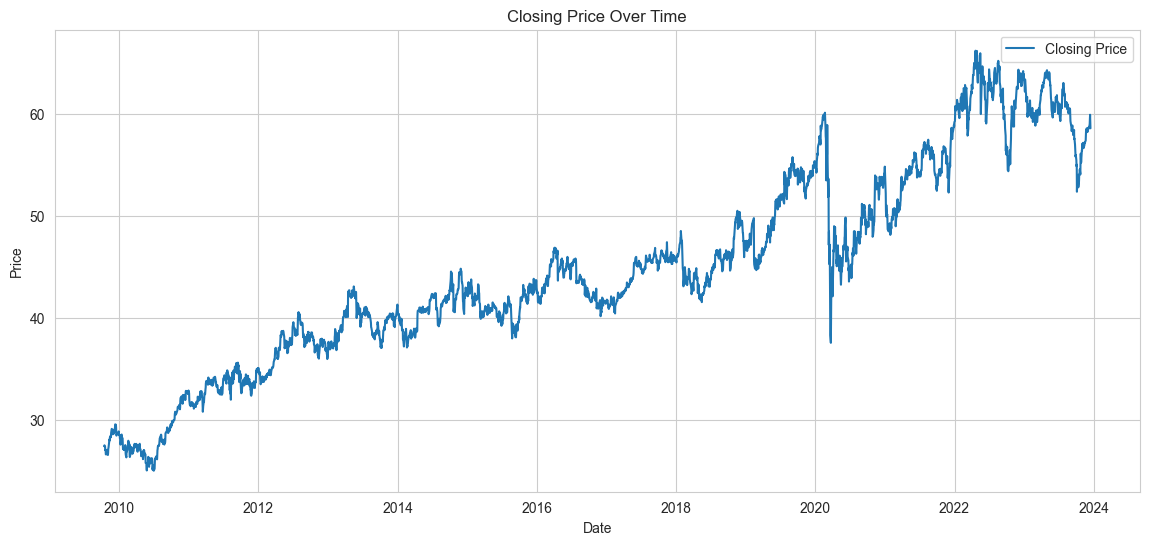

In [14]:
plt.figure()

plt.plot(df.index, df[CLOSE_COL], label="Closing Price")
plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.savefig(FIGURES_DIR / "closing_price_trend.png")
plt.show()

## Distribution of Closing Price

Understanding the distribution of the closing price helps identify:

- skewness
- heavy tails
- presence of extreme values

This is important for quantile forecasting, as the model explicitly estimates different parts of the distribution.

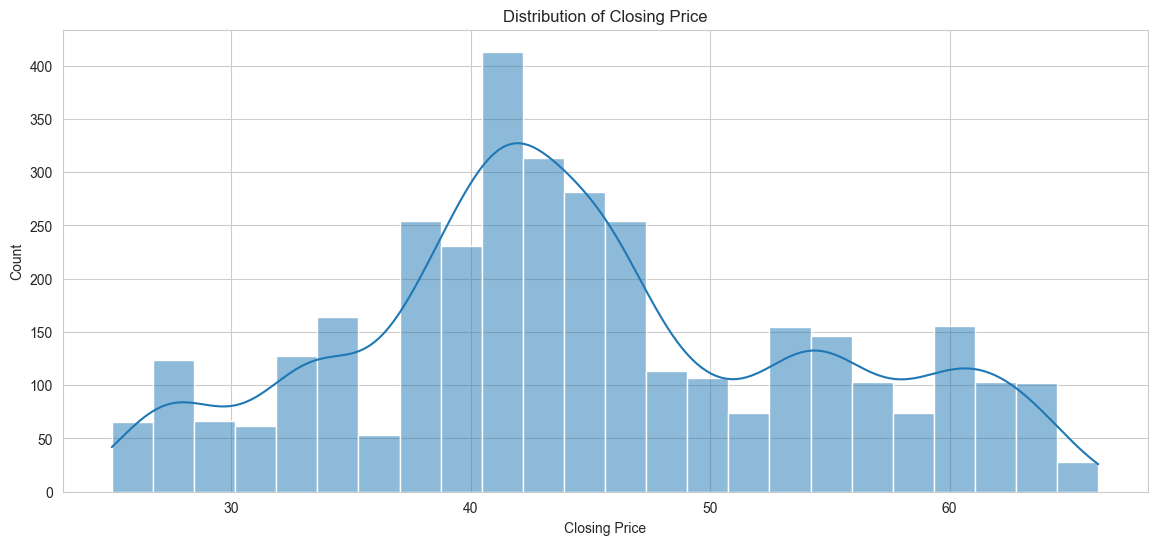

In [15]:
plt.figure()

sns.histplot(df[CLOSE_COL], kde=True)
plt.title("Distribution of Closing Price")
plt.xlabel("Closing Price")

plt.savefig(FIGURES_DIR / "closing_price_distribution.png")
plt.show()

## Outlier Analysis

Boxplots provide a simple way to visualize potential outliers in the closing price data.

Extreme values are common in financial time series and should be interpreted carefully rather than blindly removed.

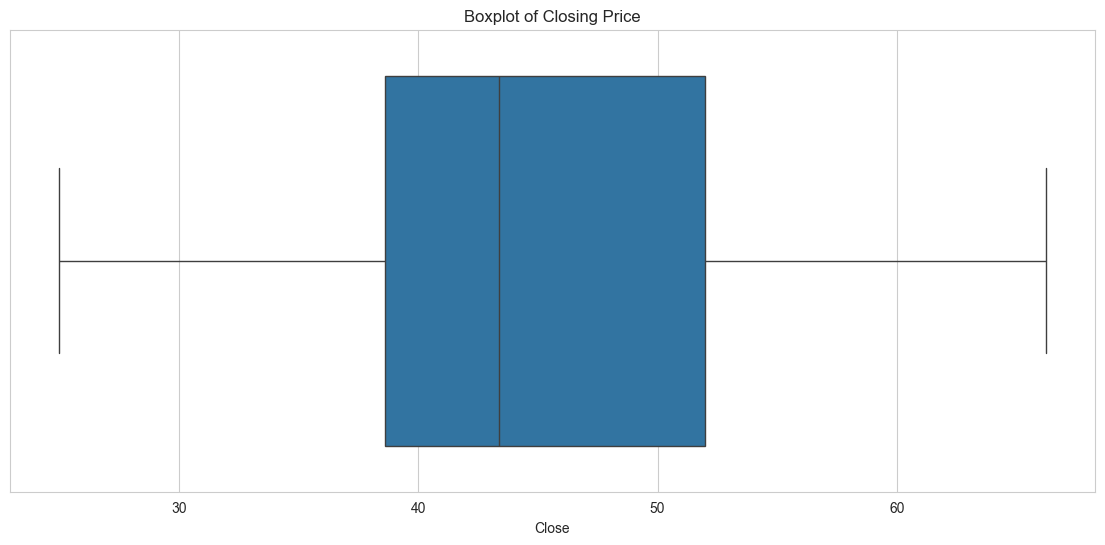

In [16]:
plt.figure()

sns.boxplot(x=df[CLOSE_COL])
plt.title("Boxplot of Closing Price")

plt.savefig(FIGURES_DIR / "closing_price_boxplot.png")
plt.show()

## Rolling Statistics

Rolling statistics help capture local trends and volatility in the time series.

We compute:

- rolling mean (trend)
- rolling standard deviation (volatility)

These features are also useful later for model training.

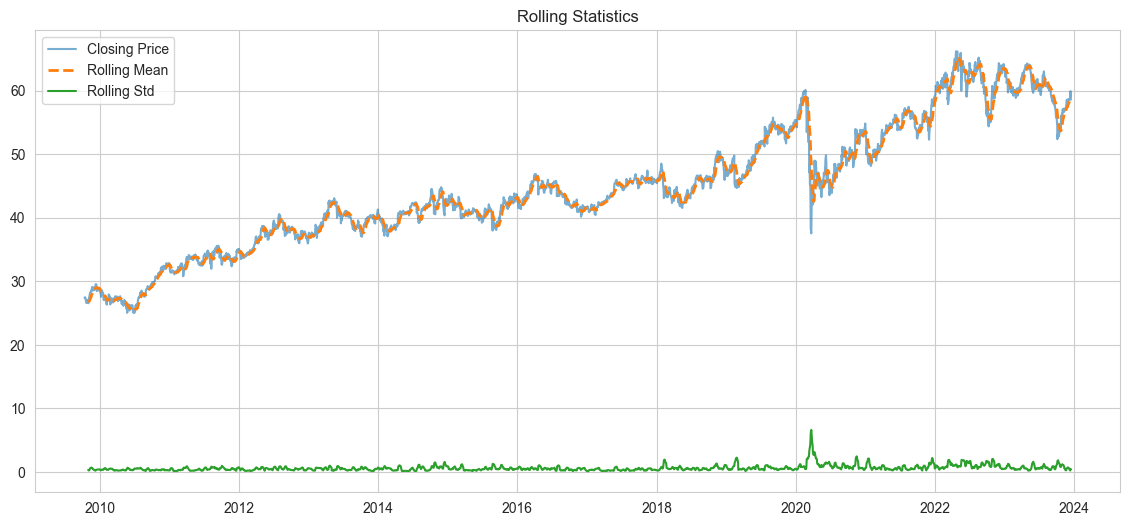

In [17]:
window = 14  # you can change this

df["rolling_mean"] = df[CLOSE_COL].rolling(window=window).mean()
df["rolling_std"] = df[CLOSE_COL].rolling(window=window).std()

plt.figure()

plt.plot(df.index, df[CLOSE_COL], label="Closing Price", alpha=0.6)
plt.plot(df.index, df["rolling_mean"], label="Rolling Mean", linewidth=2, linestyle="--")
plt.plot(df.index, df["rolling_std"], label="Rolling Std")

plt.title("Rolling Statistics")
plt.legend()

plt.savefig(FIGURES_DIR / "rolling_statistics.png")
plt.show()

## Feature Engineering

To enable effective quantile forecasting, we transform the time series into a supervised learning problem.

We construct the following features:

- **Lag features** to capture temporal dependencies
- **Rolling statistics** to capture trend and volatility
- **Returns** to capture price movement dynamics
- **Calendar features** to capture seasonal patterns

These features allow machine learning models to learn patterns from historical data without relying on sequence-based architectures.

In [18]:
# Create lag features
LAGS = [1, 2, 3, 5, 7, 14, 21]

for lag in LAGS:
    df[f"lag_{lag}"] = df[CLOSE_COL].shift(lag)

print("Lag features created.")
df[[CLOSE_COL] + [f"lag_{l}" for l in LAGS]].head(10)

Lag features created.


,Close,lag_1,lag_2,lag_3,lag_5,lag_7,lag_14,lag_21
Date,,,,,,,,
2009-10-14 00:00:00+00:00,27.420000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-10-15 00:00:00+00:00,27.459999,27.420000,NaN,NaN,NaN,NaN,NaN,NaN
2009-10-16 00:00:00+00:00,27.504999,27.459999,27.420000,NaN,NaN,NaN,NaN,NaN
2009-10-19 00:00:00+00:00,27.395000,27.504999,27.459999,27.420000,NaN,NaN,NaN,NaN
2009-10-20 00:00:00+00:00,27.035000,27.395000,27.504999,27.459999,NaN,NaN,NaN,NaN
2009-10-21 00:00:00+00:00,27.035000,27.035000,27.395000,27.504999,27.420000,NaN,NaN,NaN
2009-10-22 00:00:00+00:00,27.075001,27.035000,27.035000,27.395000,27.459999,NaN,NaN,NaN
2009-10-23 00:00:00+00:00,26.620001,27.075001,27.035000,27.035000,27.504999,27.420000,NaN,NaN
2009-10-26 00:00:00+00:00,26.615000,26.620001,27.075001,27.035000,27.395000,27.459999,NaN,NaN


## Rolling Features

Rolling statistics help capture local patterns in the data.

We compute:

- rolling mean → trend
- rolling standard deviation → volatility
- rolling min/max → local bounds

In [19]:
ROLLING_WINDOWS = [7, 14, 21]

for window in ROLLING_WINDOWS:
    df[f"roll_mean_{window}"] = df[CLOSE_COL].rolling(window).mean()
    df[f"roll_std_{window}"] = df[CLOSE_COL].rolling(window).std()
    df[f"roll_min_{window}"] = df[CLOSE_COL].rolling(window).min()
    df[f"roll_max_{window}"] = df[CLOSE_COL].rolling(window).max()

print("Rolling features created.")

Rolling features created.


## Return-Based Features

Returns capture relative price changes and are widely used in financial modeling.

We compute:

- daily returns
- rolling volatility of returns

In [20]:
# Daily returns
df["return_1"] = df[CLOSE_COL].pct_change()

# Rolling volatility of returns
df["volatility_7"] = df["return_1"].rolling(7).std()
df["volatility_14"] = df["return_1"].rolling(14).std()

print("Return-based features created.")

Return-based features created.


## Calendar Features

Time-based features can help capture periodic patterns in the data.

We extract:

- day of week
- month
- quarter

In [21]:
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["quarter"] = df.index.quarter

print("Calendar features created.")

Calendar features created.


## Final Feature Set Preparation

Before modeling, we:

- remove rows with missing values created by lag and rolling operations
- define input features (X) and target variable (y)

In [22]:
# Drop rows with NaNs caused by feature creation
df_model = df.dropna().copy()

print("Shape after dropping NA:", df_model.shape)

Shape after dropping NA: (3547, 33)


In [23]:
# Target
y = df_model[CLOSE_COL]

# Features (drop target column)
X = df_model.drop(columns=[CLOSE_COL])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (3547, 32)
Target shape: (3547,)


## Feature Distribution Check

We inspect distributions of selected engineered features to ensure they are well-behaved and suitable for modeling.

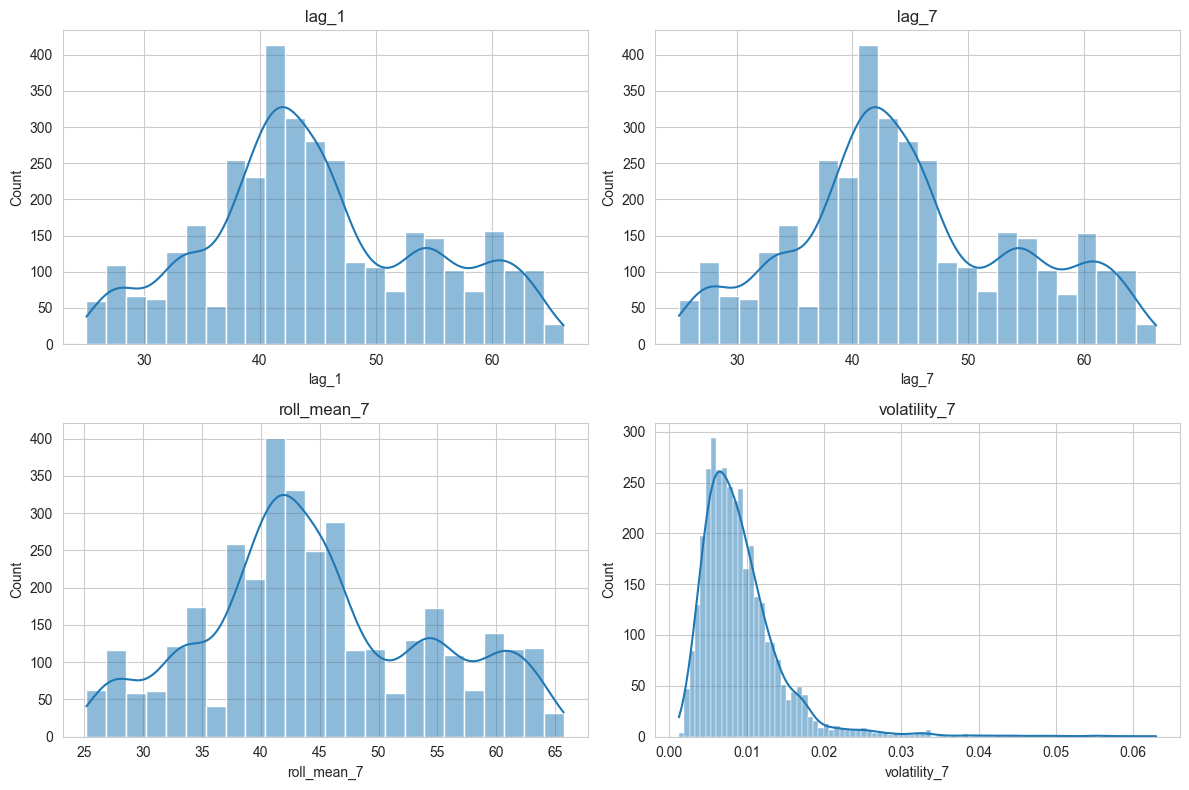

In [24]:
sample_features = ["lag_1", "lag_7", "roll_mean_7", "volatility_7"]

plt.figure(figsize=(12, 8))

for i, col in enumerate(sample_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_model[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_distributions.png")
plt.show()

In [25]:
# Compute split indices
n = len(df_model)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

# Split features
X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]

# Split target
y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (2482, 32)
Validation shape: (532, 32)
Test shape: (533, 32)


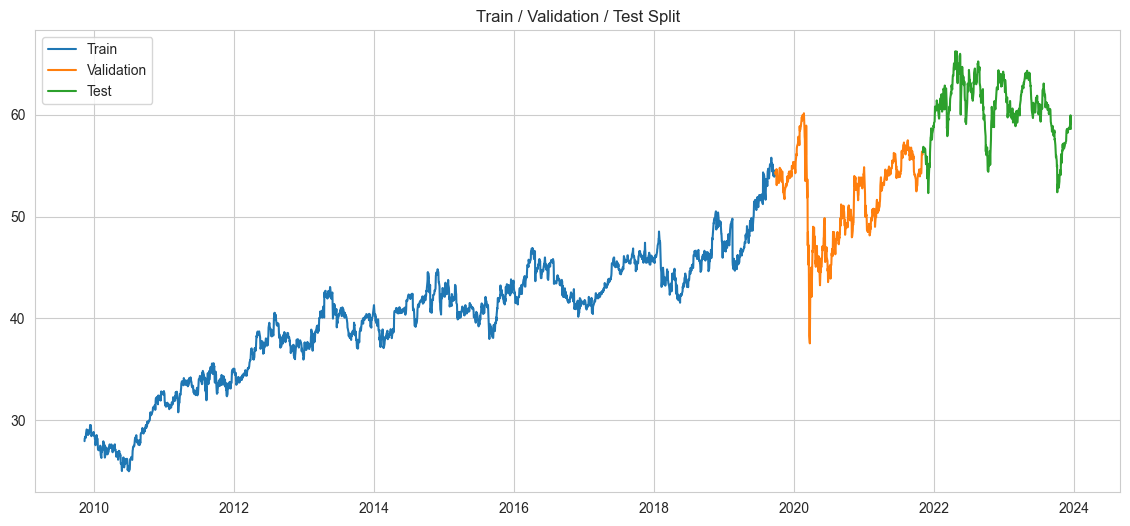

In [26]:
plt.figure()

plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_val.index, y_val, label="Validation")
plt.plot(y_test.index, y_test, label="Test")

plt.title("Train / Validation / Test Split")
plt.legend()

plt.savefig(FIGURES_DIR / "data_split.png")
plt.show()

## Baseline Model: Naive Forecast

Before training complex models, we establish a baseline using a naive approach:

Prediction = last observed value (lag_1)

This provides a simple benchmark to compare model performance.

In [27]:
# Naive prediction using lag_1
y_pred_naive = X_test["lag_1"]

# Metrics
mae_naive = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
r2_naive = r2_score(y_test, y_pred_naive)

print("Naive Model Performance:")
print("MAE:", mae_naive)
print("RMSE:", rmse_naive)
print("R2 Score: ", r2_naive)

Naive Model Performance:
MAE: 0.46562840388371396
RMSE: 0.6495428431090998
R2 Score:  0.9491793558653605


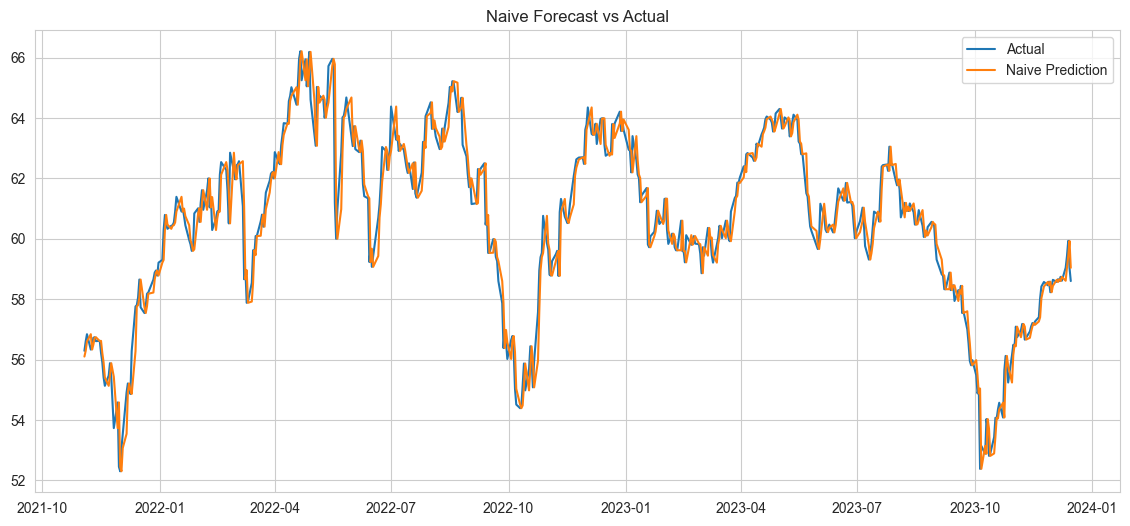

In [28]:
plt.figure()

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_naive, label="Naive Prediction")

plt.title("Naive Forecast vs Actual")
plt.legend()

plt.savefig(FIGURES_DIR / "naive_forecast.png")
plt.show()

## Baseline Model: Naive Forecast Performance

As a benchmark, we implemented a naive forecasting model where the prediction for the next time step is simply the last observed value:

Prediction(t) = Actual(t-1)

### Performance Metrics

- Mean Absolute Error (MAE): 0.466  
- Root Mean Squared Error (RMSE): 0.650  
- R² Score: 0.949  

### Interpretation

The naive model performs surprisingly well, achieving a high R² score and low error values. This is expected in financial time series due to strong autocorrelation, where consecutive values tend to be similar.

The model effectively captures short-term continuity in the data, as closing prices do not typically exhibit large changes between adjacent time steps.

### Limitations

Despite strong performance, the naive model has key limitations:

- It does not capture underlying trends or patterns
- It cannot anticipate sudden changes or volatility spikes
- It provides only point predictions without uncertainty estimates

### Role in This Project

The naive model serves as a baseline for evaluating more advanced forecasting approaches. Any developed model must either outperform this baseline or provide additional value, such as uncertainty estimation through prediction intervals.

## Linear Quantile Regression

Unlike standard regression, quantile regression estimates different conditional quantiles of the target distribution instead of only the conditional mean.

In this project, we train separate models for:

- **0.1 quantile**: lower bound prediction
- **0.5 quantile**: median prediction
- **0.9 quantile**: upper bound prediction

Together, these estimates form a prediction interval that helps quantify uncertainty in future closing price forecasts.

In [29]:
# Define quantiles
quantiles = [0.1, 0.5, 0.9]

# Store models
qr_models = {}

# Train one model per quantile
for q in quantiles:
    model = QuantileRegressor(quantile=q, alpha=0.0, solver="highs")
    model.fit(X_train, y_train)
    qr_models[q] = model

print("Linear Quantile Regression models trained successfully.")

Linear Quantile Regression models trained successfully.


## Validation Set Predictions

To assess model performance before final testing, we first generate predictions on the validation set.

This allows us to understand how well the model estimates:

- the lower quantile
- the median forecast
- the upper quantile

In [30]:
# Generate validation predictions
qr_val_preds = {}

for q in quantiles:
    qr_val_preds[q] = qr_models[q].predict(X_val)

# Store in DataFrame
qr_val_df = pd.DataFrame({
    "actual": y_val.values,
    "q0.1": qr_val_preds[0.1],
    "q0.5": qr_val_preds[0.5],
    "q0.9": qr_val_preds[0.9]
}, index=y_val.index)

qr_val_df.head()

,actual,q0.1,q0.5,q0.9
Date,,,,
2019-09-25 00:00:00+00:00,54.169998,54.166937,54.206479,54.250182
2019-09-26 00:00:00+00:00,54.389999,54.295659,54.338347,54.371214
2019-09-27 00:00:00+00:00,54.310001,54.274709,54.329645,54.377289
2019-09-30 00:00:00+00:00,54.439999,54.390815,54.420642,54.467658
2019-10-01 00:00:00+00:00,54.650002,54.496689,54.593737,54.637947


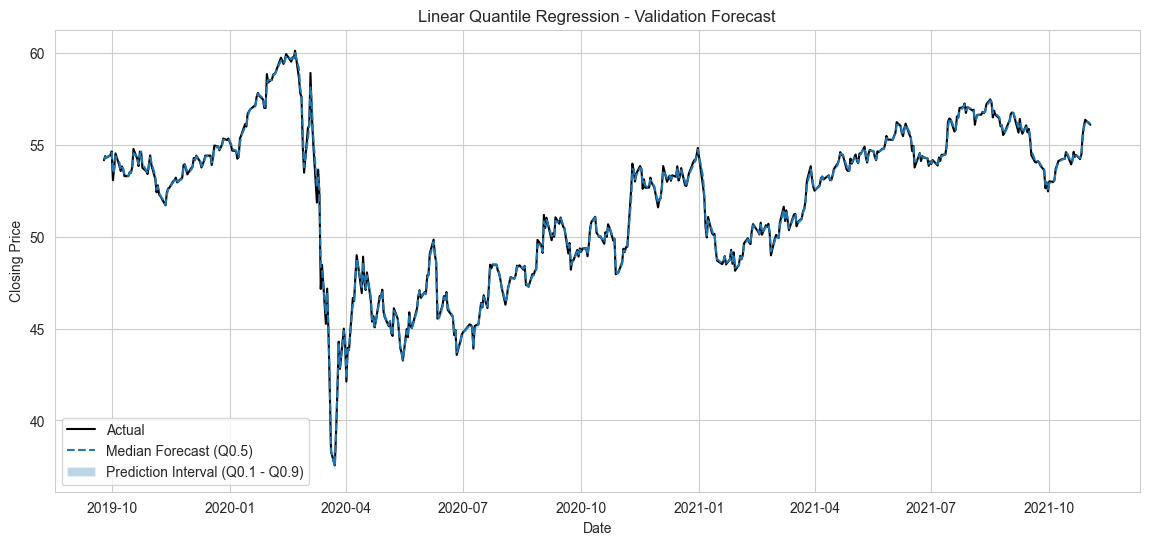

In [31]:
plt.figure(figsize=(14, 6))

plt.plot(qr_val_df.index, qr_val_df["actual"], label="Actual", color="black", linewidth=1.5)
plt.plot(qr_val_df.index, qr_val_df["q0.5"], label="Median Forecast (Q0.5)", linestyle="--", linewidth=1.5)

plt.fill_between(
    qr_val_df.index,
    qr_val_df["q0.1"],
    qr_val_df["q0.9"],
    alpha=0.3,
    label="Prediction Interval (Q0.1 - Q0.9)"
)

plt.title("Linear Quantile Regression - Validation Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.savefig(FIGURES_DIR / "linear_quantile_validation_forecast.png")
plt.show()

In [32]:
# Check average interval width
interval_width = (qr_val_df["q0.9"] - qr_val_df["q0.1"]).mean()
print("Average Interval Width:", interval_width)

Average Interval Width: 0.1744951119038914


## Improving Linear Quantile Regression

The initial linear quantile model produced very narrow prediction intervals and low coverage, indicating that uncertainty was not properly captured.

To address this, we:

- apply feature scaling
- introduce regularization
- reduce dominance of short-term lag features

These changes aim to produce more realistic and stable prediction intervals.

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [34]:
# Try stronger regularization
quantiles = [0.1, 0.5, 0.9]
qr_models_reg = {}

for q in quantiles:
    model = QuantileRegressor(
        quantile=q,
        alpha=0.1,   # ← key change (try 0.01, 0.1, 1.0)
        solver="highs"
    )
    model.fit(X_train_scaled, y_train)
    qr_models_reg[q] = model

print("Regularized quantile models trained.")

Regularized quantile models trained.


In [35]:
qr_val_preds_reg = {}

for q in quantiles:
    qr_val_preds_reg[q] = qr_models_reg[q].predict(X_val_scaled)

qr_val_reg_df = pd.DataFrame({
    "actual": y_val.values,
    "q0.1": qr_val_preds_reg[0.1],
    "q0.5": qr_val_preds_reg[0.5],
    "q0.9": qr_val_preds_reg[0.9]
}, index=y_val.index)

qr_val_reg_df.head()

,actual,q0.1,q0.5,q0.9
Date,,,,
2019-09-25 00:00:00+00:00,54.169998,53.914478,54.181589,54.226159
2019-09-26 00:00:00+00:00,54.389999,54.042659,54.324626,54.327299
2019-09-27 00:00:00+00:00,54.310001,53.918610,54.290073,54.375081
2019-09-30 00:00:00+00:00,54.439999,54.064565,54.385603,54.420280
2019-10-01 00:00:00+00:00,54.650002,53.931885,54.496115,54.510787


In [36]:
from sklearn.metrics import mean_pinball_loss

# Coverage
coverage_reg = ((y_val >= qr_val_reg_df["q0.1"]) & (y_val <= qr_val_reg_df["q0.9"])).mean()

# Interval width
interval_width_reg = (qr_val_reg_df["q0.9"] - qr_val_reg_df["q0.1"]).mean()

print("Improved Linear Quantile Model:")
print("Coverage:", coverage_reg)
print("Average Interval Width:", interval_width_reg)

Improved Linear Quantile Model:
Coverage: 0.5977443609022557
Average Interval Width: 0.6648652579770293


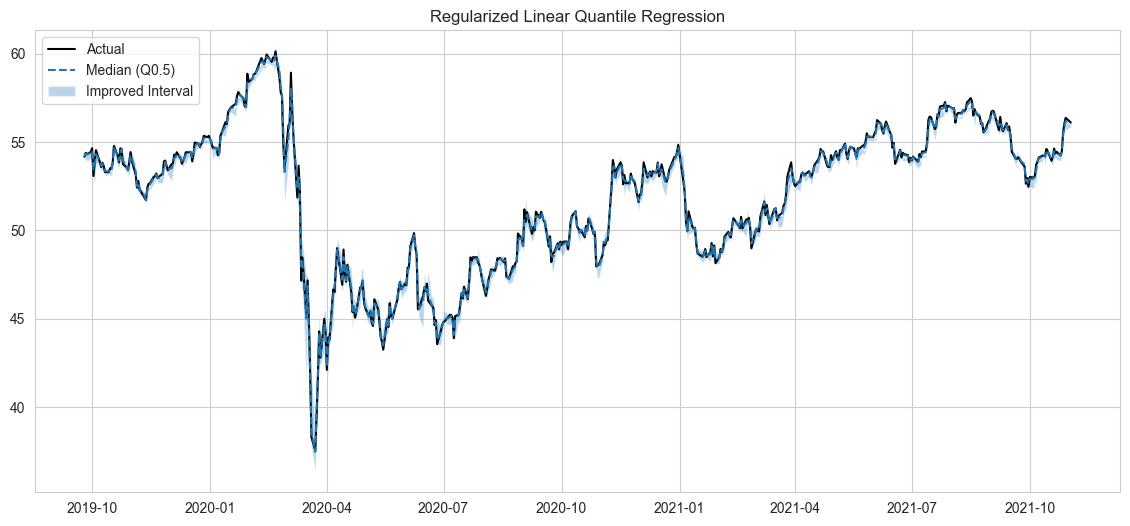

In [37]:
plt.figure(figsize=(14,6))

plt.plot(qr_val_reg_df.index, qr_val_reg_df["actual"], label="Actual", color="black")
plt.plot(qr_val_reg_df.index, qr_val_reg_df["q0.5"], label="Median (Q0.5)", linestyle="--")

plt.fill_between(
    qr_val_reg_df.index,
    qr_val_reg_df["q0.1"],
    qr_val_reg_df["q0.9"],
    alpha=0.3,
    label="Improved Interval"
)

plt.title("Regularized Linear Quantile Regression")
plt.legend()
plt.show()

In [38]:
# Drop lag_1 from features
X_train_fix = X_train.drop(columns=["lag_1"])
X_val_fix = X_val.drop(columns=["lag_1"])
X_test_fix = X_test.drop(columns=["lag_1"])

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_fix_scaled = scaler.fit_transform(X_train_fix)
X_val_fix_scaled = scaler.transform(X_val_fix)
X_test_fix_scaled = scaler.transform(X_test_fix)

In [40]:
# Much stronger regularization
quantiles = [0.1, 0.5, 0.9]
qr_models_fix = {}

for q in quantiles:
    model = QuantileRegressor(
        quantile=q,
        alpha=1.0,   # ← stronger push
        solver="highs"
    )
    model.fit(X_train_fix_scaled, y_train)
    qr_models_fix[q] = model

print("Retrained without lag_1.")

Retrained without lag_1.


In [41]:
qr_val_preds_fix = {}

for q in quantiles:
    qr_val_preds_fix[q] = qr_models_fix[q].predict(X_val_fix_scaled)

qr_val_fix_df = pd.DataFrame({
    "actual": y_val.values,
    "q0.1": qr_val_preds_fix[0.1],
    "q0.5": qr_val_preds_fix[0.5],
    "q0.9": qr_val_preds_fix[0.9]
}, index=y_val.index)

In [42]:
coverage_fix = ((y_val >= qr_val_fix_df["q0.1"]) & (y_val <= qr_val_fix_df["q0.9"])).mean()
interval_width_fix = (qr_val_fix_df["q0.9"] - qr_val_fix_df["q0.1"]).mean()

print("After removing lag_1:")
print("Coverage:", coverage_fix)
print("Interval Width:", interval_width_fix)

After removing lag_1:
Coverage: 0.11090225563909774
Interval Width: 15.28499984741211


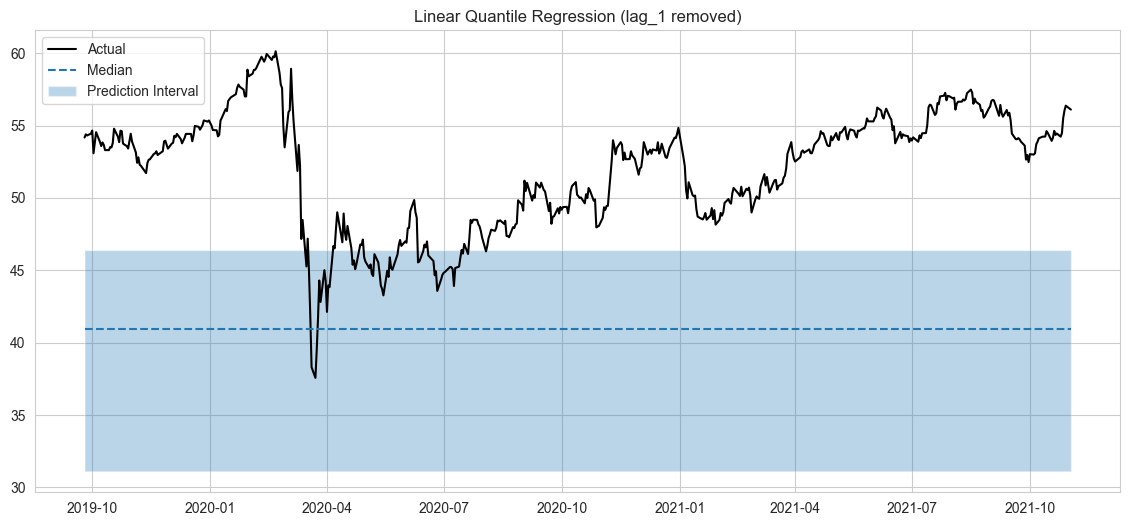

In [43]:
plt.figure(figsize=(14,6))

plt.plot(qr_val_fix_df.index, qr_val_fix_df["actual"], label="Actual", color="black")
plt.plot(qr_val_fix_df.index, qr_val_fix_df["q0.5"], label="Median", linestyle="--")

plt.fill_between(
    qr_val_fix_df.index,
    qr_val_fix_df["q0.1"],
    qr_val_fix_df["q0.9"],
    alpha=0.3,
    label="Prediction Interval"
)

plt.title("Linear Quantile Regression (lag_1 removed)")
plt.legend()
plt.show()

## Limitations of Linear Quantile Regression

Two variations of linear quantile regression were tested:

1. Including lag_1 feature:
   - Produced highly accurate median predictions
   - However, prediction intervals were extremely narrow
   - This resulted in poor coverage and overconfidence

2. Excluding lag_1 feature:
   - Increased interval width
   - However, the model failed to capture time dynamics
   - Predictions became nearly constant across time

These results highlight a key limitation of linear models:

They are unable to simultaneously capture:
- strong short-term dependencies
- nonlinear patterns
- dynamic changes in volatility

As a result, linear quantile regression is not well-suited for this dataset.

To address these issues, a more flexible non-linear model is required.

## Gradient Boosting Quantile Regression

To overcome the limitations of linear models, we use Gradient Boosting Regressors configured for quantile loss.

These models can:
- capture nonlinear relationships
- adapt to changing volatility
- produce dynamic prediction intervals

We train separate models for:
- 0.1 quantile (lower bound)
- 0.5 quantile (median)
- 0.9 quantile (upper bound)

In [44]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_models = {}

for q in [0.1, 0.5, 0.9]:
    model = GradientBoostingRegressor(
        loss="quantile",
        alpha=q,
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        min_samples_leaf=10,
        random_state=42
    )
    model.fit(X_train, y_train)
    gbr_models[q] = model

print("Improved GBR models trained.")

Improved GBR models trained.


In [45]:
gbr_val_preds = {}

for q in [0.1, 0.5, 0.9]:
    gbr_val_preds[q] = gbr_models[q].predict(X_val)

gbr_val_df = pd.DataFrame({
    "actual": y_val.values,
    "q0.1": gbr_val_preds[0.1],
    "q0.5": gbr_val_preds[0.5],
    "q0.9": gbr_val_preds[0.9]
}, index=y_val.index)

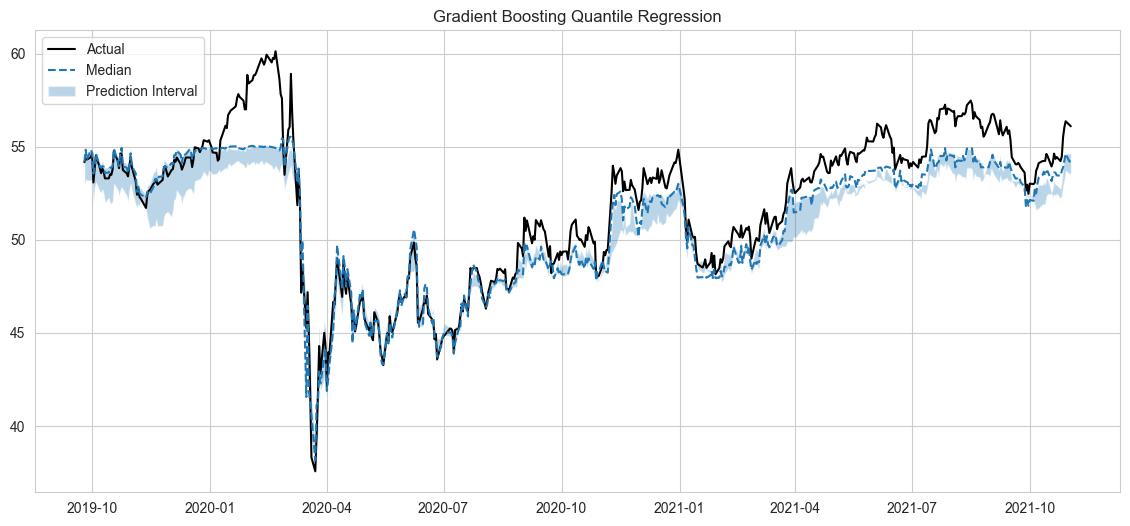

In [46]:
plt.figure(figsize=(14,6))

plt.plot(gbr_val_df.index, gbr_val_df["actual"], label="Actual", color="black")
plt.plot(gbr_val_df.index, gbr_val_df["q0.5"], label="Median", linestyle="--")

plt.fill_between(
    gbr_val_df.index,
    gbr_val_df["q0.1"],
    gbr_val_df["q0.9"],
    alpha=0.3,
    label="Prediction Interval"
)

plt.title("Gradient Boosting Quantile Regression")
plt.legend()
plt.show()

In [47]:
coverage_gbr = ((y_val >= gbr_val_df["q0.1"]) & (y_val <= gbr_val_df["q0.9"])).mean()
interval_width_gbr = (gbr_val_df["q0.9"] - gbr_val_df["q0.1"]).mean()

print("GBR Coverage:", coverage_gbr)
print("GBR Interval Width:", interval_width_gbr)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Median prediction (Q0.5)
y_pred_median = gbr_val_df["q0.5"]

# Metrics
mae_gbr = mean_absolute_error(y_val, y_pred_median)
mse_gbr = mean_squared_error(y_val, y_pred_median)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_val, y_pred_median)

print("Gradient Boosting (Median Forecast) Metrics:")
print(f"MAE: {mae_gbr:.4f}")
print(f"MSE: {mse_gbr:.4f}")
print(f"RMSE: {rmse_gbr:.4f}")
print(f"R² Score: {r2_gbr:.4f}")

GBR Coverage: 0.2274436090225564
GBR Interval Width: 0.8644966436912039
Gradient Boosting (Median Forecast) Metrics:
MAE: 1.0718
MSE: 1.9818
RMSE: 1.4078
R² Score: 0.8764


## Limitation of Raw-Price GBR

The initial Gradient Boosting Quantile model trained directly on raw closing prices captured the broad trend reasonably well, but its prediction intervals remained poorly calibrated.

In particular, the model showed sensitivity to the COVID crash regime, which introduced systematic bias and reduced interval reliability. This suggested that modeling absolute prices directly was not ideal for a non-stationary financial time series.

To address this, the final model was reformulated as a one-step-ahead return forecasting problem. This leakage-safe setup uses only information available up to time \(t\) to predict the return at time \(t+1\), and then reconstructs the next-day closing price.

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Final Leakage-Safe GBR Using Return-Based Forecasting

To make the forecasting setup more realistic and robust, the final Gradient Boosting Quantile model is trained on **next-day returns** rather than raw prices.

This approach offers three key advantages:

- it reduces the effect of non-stationarity in raw price levels
- it prevents information leakage by aligning features at time \(t\) with target return at time \(t+1\)
- it reduces the disproportionate influence of extreme events such as the COVID crash

The predicted return is then converted back into the next-day closing price for evaluation and visualization.

In [48]:
# Rebuild leakage-safe feature frame from the cleaned time series
df_feat = df.copy()

# Lag features
LAGS = [1, 2, 3, 5, 7, 14, 21]
for lag in LAGS:
    df_feat[f"lag_{lag}"] = df_feat[CLOSE_COL].shift(lag)

# Rolling features using only past information
ROLLING_WINDOWS = [7, 14, 21]
for window in ROLLING_WINDOWS:
    df_feat[f"roll_mean_{window}"] = df_feat[CLOSE_COL].shift(1).rolling(window).mean()
    df_feat[f"roll_std_{window}"] = df_feat[CLOSE_COL].shift(1).rolling(window).std()
    df_feat[f"roll_min_{window}"] = df_feat[CLOSE_COL].shift(1).rolling(window).min()
    df_feat[f"roll_max_{window}"] = df_feat[CLOSE_COL].shift(1).rolling(window).max()

# Returns and volatility using past information only
df_feat["return_1"] = df_feat[CLOSE_COL].pct_change().shift(1)
df_feat["volatility_7"] = df_feat["return_1"].rolling(7).std()
df_feat["volatility_14"] = df_feat["return_1"].rolling(14).std()

# Calendar features
df_feat["day_of_week"] = df_feat.index.dayofweek
df_feat["month"] = df_feat.index.month
df_feat["quarter"] = df_feat.index.quarter

# Next-day return target
df_feat["target_return_next"] = df_feat[CLOSE_COL].pct_change().shift(-1)

# Final leakage-safe modeling frame
df_model_safe = df_feat.dropna().copy()

df_model_safe.head()

,Volume,Open,High,Low,Close,Adj close,rolling_mean,rolling_std,lag_1,lag_2,...,roll_std_21,roll_min_21,roll_max_21,return_1,volatility_7,volatility_14,day_of_week,month,quarter,target_return_next
Date,,,,,,,,,,,,,,,,,,,,,
2009-11-12 00:00:00+00:00,15196000.0,28.055000,28.190001,27.924999,27.969999,18.485298,27.149286,0.548438,28.065001,27.905001,...,0.441284,26.559999,28.065001,0.005734,0.009859,0.010577,3,11,4,0.009296
2009-11-13 00:00:00+00:00,23351000.0,28.030001,28.350000,27.950001,28.230000,18.657129,27.264643,0.595262,27.969999,28.065001,...,0.474612,26.559999,28.065001,-0.003385,0.007775,0.009199,4,11,4,0.004959
2009-11-16 00:00:00+00:00,16239400.0,28.325001,28.545000,28.215000,28.370001,18.749659,27.381786,0.641526,28.230000,27.969999,...,0.526423,26.559999,28.230000,0.009296,0.007801,0.009249,0,11,4,0.002291
2009-11-17 00:00:00+00:00,11344000.0,28.320000,28.459999,28.225000,28.434999,18.792608,27.501786,0.671681,28.370001,28.230000,...,0.583112,26.559999,28.370001,0.004959,0.006671,0.009251,1,11,4,-0.005099
2009-11-18 00:00:00+00:00,15253200.0,28.465000,28.500000,28.145000,28.290001,18.696787,27.590715,0.688753,28.434999,28.370001,...,0.639206,26.559999,28.434999,0.002291,0.006605,0.009220,2,11,4,0.005302


In [49]:
# Define X and y
X_safe = df_model_safe.drop(columns=[CLOSE_COL, "target_return_next"])
y_safe = df_model_safe["target_return_next"]

# Time-based split: 70 / 15 / 15
n_safe = len(df_model_safe)
train_end_safe = int(n_safe * 0.7)
val_end_safe = int(n_safe * 0.85)

X_train_safe = X_safe.iloc[:train_end_safe]
X_val_safe = X_safe.iloc[train_end_safe:val_end_safe]
X_test_safe = X_safe.iloc[val_end_safe:]

y_train_safe = y_safe.iloc[:train_end_safe]
y_val_safe = y_safe.iloc[train_end_safe:val_end_safe]
y_test_safe = y_safe.iloc[val_end_safe:]

print("Train shape:", X_train_safe.shape)
print("Validation shape:", X_val_safe.shape)
print("Test shape:", X_test_safe.shape)

Train shape: (2482, 32)
Validation shape: (532, 32)
Test shape: (532, 32)


In [50]:
# Cap extreme training returns using training-only quantiles
lower_q = y_train_safe.quantile(0.01)
upper_q = y_train_safe.quantile(0.99)

y_train_safe_clip = y_train_safe.clip(lower=lower_q, upper=upper_q)

print("Lower cap:", lower_q)
print("Upper cap:", upper_q)

Lower cap: -0.025373952614220645
Upper cap: 0.02163536369517336


In [51]:
from sklearn.ensemble import GradientBoostingRegressor

quantiles = [0.1, 0.5, 0.9]
gbr_final_models = {}

for q in quantiles:
    model = GradientBoostingRegressor(
        loss="quantile",
        alpha=q,
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        min_samples_leaf=10,
        random_state=42
    )
    model.fit(X_train_safe, y_train_safe_clip)
    gbr_final_models[q] = model

print("Leakage-safe GBR models trained.")

Leakage-safe GBR models trained.


In [52]:
# Validation predictions in return space
val_pred_ret = {}

for q in quantiles:
    val_pred_ret[q] = gbr_final_models[q].predict(X_val_safe)

In [53]:
# Reconstruct next-day prices on validation set
current_prices_val = df_model_safe[CLOSE_COL].iloc[train_end_safe:val_end_safe].values

pred_price_low = current_prices_val * (1 + val_pred_ret[0.1])
pred_price_med = current_prices_val * (1 + val_pred_ret[0.5])
pred_price_high = current_prices_val * (1 + val_pred_ret[0.9])

actual_next_prices_val = df_model_safe[CLOSE_COL].shift(-1).iloc[train_end_safe:val_end_safe].values

gbr_val_final_df = pd.DataFrame({
    "actual": actual_next_prices_val,
    "q0.1": pred_price_low,
    "q0.5": pred_price_med,
    "q0.9": pred_price_high
}, index=df_model_safe.index[train_end_safe:val_end_safe])

gbr_val_final_df = gbr_val_final_df.dropna()
gbr_val_final_df.head()

,actual,q0.1,q0.5,q0.9
Date,,,,
2019-09-25 00:00:00+00:00,54.389999,53.622405,54.252520,54.444787
2019-09-26 00:00:00+00:00,54.310001,53.595025,54.261869,54.695088
2019-09-27 00:00:00+00:00,54.439999,53.617589,54.369188,54.496472
2019-09-30 00:00:00+00:00,54.650002,53.613462,54.311392,54.798326
2019-10-01 00:00:00+00:00,53.080002,53.778803,54.685739,55.211442


In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true_val = gbr_val_final_df["actual"]
y_med_val = gbr_val_final_df["q0.5"]

mae_val = mean_absolute_error(y_true_val, y_med_val)
mse_val = mean_squared_error(y_true_val, y_med_val)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_true_val, y_med_val)

coverage_val = ((y_true_val >= gbr_val_final_df["q0.1"]) & (y_true_val <= gbr_val_final_df["q0.9"])).mean()
interval_width_val = (gbr_val_final_df["q0.9"] - gbr_val_final_df["q0.1"]).mean()

print("Validation Results")
print(f"MAE: {mae_val:.4f}")
print(f"MSE: {mse_val:.4f}")
print(f"RMSE: {rmse_val:.4f}")
print(f"R2: {r2_val:.4f}")
print(f"Coverage (Q0.1-Q0.9): {coverage_val:.4f}")
print(f"Average Interval Width: {interval_width_val:.4f}")

Validation Results
MAE: 0.5328
MSE: 0.6674
RMSE: 0.8170
R2: 0.9584
Coverage (Q0.1-Q0.9): 0.6842
Average Interval Width: 1.1751


In [55]:
violations_val = ((gbr_val_final_df["q0.1"] > gbr_val_final_df["q0.5"]) |
                  (gbr_val_final_df["q0.5"] > gbr_val_final_df["q0.9"])).sum()

bias_val = (y_true_val - y_med_val).mean()

print("Quantile ordering violations:", violations_val)
print("Median forecast bias:", round(bias_val, 4))

Quantile ordering violations: 0
Median forecast bias: -0.021


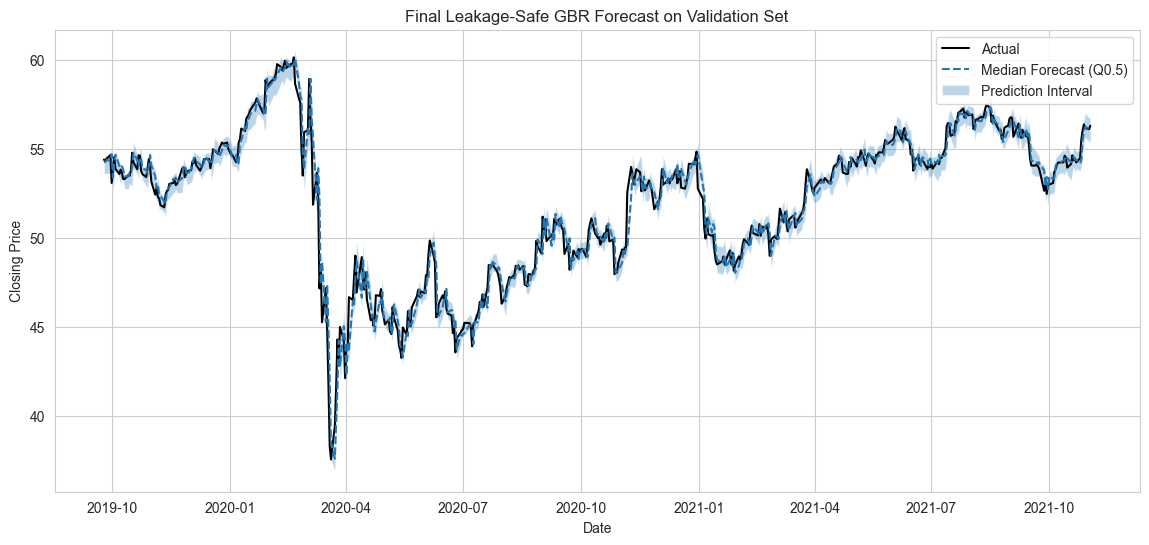

In [56]:
plt.figure(figsize=(14, 6))

plt.plot(gbr_val_final_df.index, gbr_val_final_df["actual"], label="Actual", color="black", linewidth=1.5)
plt.plot(gbr_val_final_df.index, gbr_val_final_df["q0.5"], label="Median Forecast (Q0.5)", linestyle="--", linewidth=1.5)

plt.fill_between(
    gbr_val_final_df.index,
    gbr_val_final_df["q0.1"],
    gbr_val_final_df["q0.9"],
    alpha=0.3,
    label="Prediction Interval"
)

plt.title("Final Leakage-Safe GBR Forecast on Validation Set")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.savefig(FIGURES_DIR / "final_gbr_validation_forecast.png")
plt.show()

## Final Test Set Evaluation

After validating the leakage-safe return-based forecasting setup, the final model is trained on the combined training and validation sets and evaluated once on the held-out test set.

This provides the final out-of-sample assessment of both point forecast accuracy and interval reliability.

In [57]:
# Combine training and validation sets
X_trainval_safe = pd.concat([X_train_safe, X_val_safe], axis=0)
y_trainval_safe = pd.concat([y_train_safe, y_val_safe], axis=0)

# Cap using train+validation only
lower_q_tv = y_trainval_safe.quantile(0.01)
upper_q_tv = y_trainval_safe.quantile(0.99)
y_trainval_safe_clip = y_trainval_safe.clip(lower=lower_q_tv, upper=upper_q_tv)

# Retrain final models
gbr_test_models = {}

for q in quantiles:
    model = GradientBoostingRegressor(
        loss="quantile",
        alpha=q,
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        min_samples_leaf=10,
        random_state=42
    )
    model.fit(X_trainval_safe, y_trainval_safe_clip)
    gbr_test_models[q] = model

print("Final models retrained on Train + Validation.")

Final models retrained on Train + Validation.


In [58]:
# Predict returns on test set
test_pred_ret = {}

for q in quantiles:
    test_pred_ret[q] = gbr_test_models[q].predict(X_test_safe)

# Reconstruct next-day prices on test set
current_prices_test = df_model_safe[CLOSE_COL].iloc[val_end_safe:].values

pred_price_low_test = current_prices_test * (1 + test_pred_ret[0.1])
pred_price_med_test = current_prices_test * (1 + test_pred_ret[0.5])
pred_price_high_test = current_prices_test * (1 + test_pred_ret[0.9])

actual_next_prices_test = df_model_safe[CLOSE_COL].shift(-1).iloc[val_end_safe:].values

gbr_test_df = pd.DataFrame({
    "actual": actual_next_prices_test,
    "q0.1": pred_price_low_test,
    "q0.5": pred_price_med_test,
    "q0.9": pred_price_high_test
}, index=df_model_safe.index[val_end_safe:])

gbr_test_df = gbr_test_df.dropna()
gbr_test_df.head()

,actual,q0.1,q0.5,q0.9
Date,,,,
2021-11-03 00:00:00+00:00,56.599998,55.815921,56.341007,56.655616
2021-11-04 00:00:00+00:00,56.840000,56.163154,56.616773,56.915699
2021-11-05 00:00:00+00:00,56.330002,56.326263,56.922065,57.180392
2021-11-08 00:00:00+00:00,56.490002,55.909983,56.440806,56.727187
2021-11-09 00:00:00+00:00,56.720001,56.038947,56.558387,56.986134


In [59]:
y_true_test = gbr_test_df["actual"]
y_med_test = gbr_test_df["q0.5"]

mae_test = mean_absolute_error(y_true_test, y_med_test)
mse_test = mean_squared_error(y_true_test, y_med_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_true_test, y_med_test)

coverage_test = ((y_true_test >= gbr_test_df["q0.1"]) & (y_true_test <= gbr_test_df["q0.9"])).mean()
interval_width_test = (gbr_test_df["q0.9"] - gbr_test_df["q0.1"]).mean()

violations_test = ((gbr_test_df["q0.1"] > gbr_test_df["q0.5"]) |
                   (gbr_test_df["q0.5"] > gbr_test_df["q0.9"])).sum()

bias_test = (y_true_test - y_med_test).mean()

print("Final Test Results")
print(f"MAE: {mae_test:.4f}")
print(f"MSE: {mse_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R2: {r2_test:.4f}")
print(f"Coverage (Q0.1-Q0.9): {coverage_test:.4f}")
print(f"Average Interval Width: {interval_width_test:.4f}")
print(f"Quantile ordering violations on test set: {violations_test}")
print(f"Median forecast bias on test set: {bias_test:.4f}")

Final Test Results
MAE: 0.7013
MSE: 0.7743
RMSE: 0.8800
R2: 0.9066
Coverage (Q0.1-Q0.9): 0.8625
Average Interval Width: 2.4328
Quantile ordering violations on test set: 0
Median forecast bias on test set: 0.5470


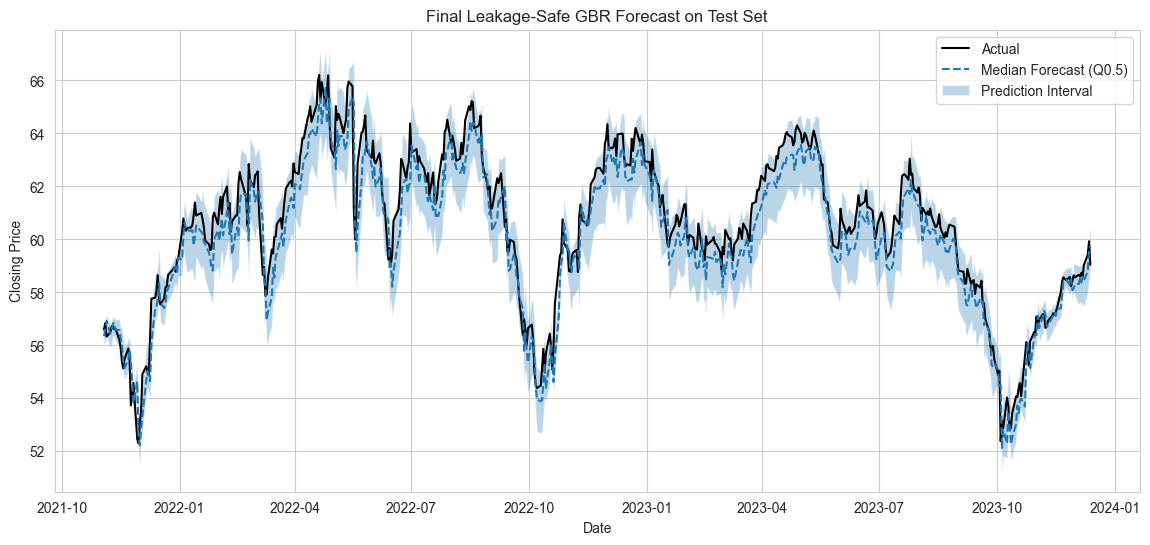

In [60]:
plt.figure(figsize=(14, 6))

plt.plot(gbr_test_df.index, gbr_test_df["actual"], label="Actual", color="black", linewidth=1.5)
plt.plot(gbr_test_df.index, gbr_test_df["q0.5"], label="Median Forecast (Q0.5)", linestyle="--", linewidth=1.5)

plt.fill_between(
    gbr_test_df.index,
    gbr_test_df["q0.1"],
    gbr_test_df["q0.9"],
    alpha=0.3,
    label="Prediction Interval"
)

plt.title("Final Leakage-Safe GBR Forecast on Test Set")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.savefig(FIGURES_DIR / "final_gbr_test_forecast.png")
plt.show()

## Pinball Loss for Quantile Evaluation

Since this project focuses on quantile forecasting, standard point forecast metrics alone are not sufficient.

To evaluate the quality of the lower, median, and upper quantile predictions, we use **pinball loss**, which is the standard loss function for quantile regression.

Lower pinball loss indicates better quantile estimation.

In this notebook, pinball loss is computed for:

- **Q0.1**: lower quantile
- **Q0.5**: median quantile
- **Q0.9**: upper quantile

In [61]:
from sklearn.metrics import mean_pinball_loss

# Validation pinball losses
pinball_q10_val = mean_pinball_loss(y_true_val, gbr_val_final_df["q0.1"], alpha=0.1)
pinball_q50_val = mean_pinball_loss(y_true_val, gbr_val_final_df["q0.5"], alpha=0.5)
pinball_q90_val = mean_pinball_loss(y_true_val, gbr_val_final_df["q0.9"], alpha=0.9)

avg_pinball_val = np.mean([pinball_q10_val, pinball_q50_val, pinball_q90_val])

print("Validation Pinball Loss")
print(f"Pinball Loss (Q0.1): {pinball_q10_val:.4f}")
print(f"Pinball Loss (Q0.5): {pinball_q50_val:.4f}")
print(f"Pinball Loss (Q0.9): {pinball_q90_val:.4f}")
print(f"Average Pinball Loss: {avg_pinball_val:.4f}")

Validation Pinball Loss
Pinball Loss (Q0.1): 0.1536
Pinball Loss (Q0.5): 0.2664
Pinball Loss (Q0.9): 0.1402
Average Pinball Loss: 0.1867


In [62]:
# Test pinball losses
pinball_q10_test = mean_pinball_loss(y_true_test, gbr_test_df["q0.1"], alpha=0.1)
pinball_q50_test = mean_pinball_loss(y_true_test, gbr_test_df["q0.5"], alpha=0.5)
pinball_q90_test = mean_pinball_loss(y_true_test, gbr_test_df["q0.9"], alpha=0.9)

avg_pinball_test = np.mean([pinball_q10_test, pinball_q50_test, pinball_q90_test])

print("Test Pinball Loss")
print(f"Pinball Loss (Q0.1): {pinball_q10_test:.4f}")
print(f"Pinball Loss (Q0.5): {pinball_q50_test:.4f}")
print(f"Pinball Loss (Q0.9): {pinball_q90_test:.4f}")
print(f"Average Pinball Loss: {avg_pinball_test:.4f}")

Test Pinball Loss
Pinball Loss (Q0.1): 0.1901
Pinball Loss (Q0.5): 0.3506
Pinball Loss (Q0.9): 0.1073
Average Pinball Loss: 0.2160


In [63]:
final_test_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "Coverage",
        "Average Interval Width",
        "Bias",
        "Quantile Violations",
        "Pinball Loss Q0.1",
        "Pinball Loss Q0.5",
        "Pinball Loss Q0.9",
        "Average Pinball Loss"
    ],
    "Value": [
        mae_test,
        mse_test,
        rmse_test,
        r2_test,
        coverage_test,
        interval_width_test,
        bias_test,
        violations_test,
        pinball_q10_test,
        pinball_q50_test,
        pinball_q90_test,
        avg_pinball_test
    ]
})

final_test_metrics.to_csv(METRICS_DIR / "non_sentimental_gbr_test_metrics.csv", index=False)
final_test_metrics

,Metric,Value
0,MAE,0.701284
1,MSE,0.774340
2,RMSE,0.879966
3,R2,0.906631
4,Coverage,0.862524
5,Average Interval Width,2.432822
6,Bias,0.547033
7,Quantile Violations,0.000000
8,Pinball Loss Q0.1,0.190116
9,Pinball Loss Q0.5,0.350642


In [64]:
pinball_summary = pd.DataFrame({
    "Quantile": ["Q0.1", "Q0.5", "Q0.9", "Average"],
    "Validation": [pinball_q10_val, pinball_q50_val, pinball_q90_val, avg_pinball_val],
    "Test": [pinball_q10_test, pinball_q50_test, pinball_q90_test, avg_pinball_test]
})

pinball_summary

,Quantile,Validation,Test
0,Q0.1,0.153616,0.190116
1,Q0.5,0.266395,0.350642
2,Q0.9,0.140178,0.107292
3,Average,0.186730,0.216017


## LightGBM Quantile Regression

To further strengthen the forecasting analysis, we implement a LightGBM-based quantile regression model.

LightGBM is a gradient boosting framework that is often more flexible and efficient than standard boosting approaches. In this notebook, it is used to predict:

- **Q0.025**: lower bound
- **Q0.5**: median forecast
- **Q0.975**: upper bound

To remain consistent with the final GBR setup, LightGBM is trained in the same leakage-safe one-step-ahead return forecasting framework, and the predicted returns are converted back into closing prices for evaluation.

In [65]:
import lightgbm as lgb
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_pinball_loss
)

In [66]:
# Reuse leakage-safe data from the GBR pipeline:
# X_train_safe, X_val_safe, X_test_safe
# y_train_safe, y_val_safe, y_test_safe
# df_model_safe, CLOSE_COL
# train_end_safe, val_end_safe

# Clip extreme training returns using training-only quantiles
lower_q_lgb = y_train_safe.quantile(0.01)
upper_q_lgb = y_train_safe.quantile(0.99)

y_train_safe_clip_lgb = y_train_safe.clip(lower=lower_q_lgb, upper=upper_q_lgb)

print("Lower cap:", lower_q_lgb)
print("Upper cap:", upper_q_lgb)

Lower cap: -0.025373952614220645
Upper cap: 0.02163536369517336


In [76]:
quantiles_lgb = [0.025, 0.5, 0.975]
lgb_models = {}

common_params = {
    "objective": "quantile",
    "n_estimators": 500,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "max_depth": 6,
    "min_child_samples": 10,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "verbosity": -1
}

for q in quantiles_lgb:
    model = lgb.LGBMRegressor(alpha=q, **common_params)
    model.fit(X_train_safe, y_train_safe_clip_lgb)
    lgb_models[q] = model

print("LightGBM quantile models trained successfully.")

LightGBM quantile models trained successfully.


In [77]:
# Predict next-day returns on validation set
lgb_val_pred_ret = {}

for q in quantiles_lgb:
    lgb_val_pred_ret[q] = lgb_models[q].predict(X_val_safe)

# Reconstruct next-day prices on validation set
current_prices_val_lgb = df_model_safe[CLOSE_COL].iloc[train_end_safe:val_end_safe].values

pred_price_low_lgb = current_prices_val_lgb * (1 + lgb_val_pred_ret[0.025])
pred_price_med_lgb = current_prices_val_lgb * (1 + lgb_val_pred_ret[0.5])
pred_price_high_lgb = current_prices_val_lgb * (1 + lgb_val_pred_ret[0.975])

actual_next_prices_val_lgb = df_model_safe[CLOSE_COL].shift(-1).iloc[train_end_safe:val_end_safe].values

lgb_val_df = pd.DataFrame({
    "actual": actual_next_prices_val_lgb,
    "q0.025": pred_price_low_lgb,
    "q0.5": pred_price_med_lgb,
    "q0.975": pred_price_high_lgb
}, index=df_model_safe.index[train_end_safe:val_end_safe])

lgb_val_df = lgb_val_df.dropna()
lgb_val_df.head()

,actual,q0.025,q0.5,q0.975
Date,,,,
2019-09-25 00:00:00+00:00,54.389999,53.542584,54.080762,54.468396
2019-09-26 00:00:00+00:00,54.310001,53.764534,54.325941,54.805872
2019-09-27 00:00:00+00:00,54.439999,53.683508,54.212293,54.778204
2019-09-30 00:00:00+00:00,54.650002,53.875120,54.369315,54.985216
2019-10-01 00:00:00+00:00,53.080002,53.787604,54.728100,55.333374


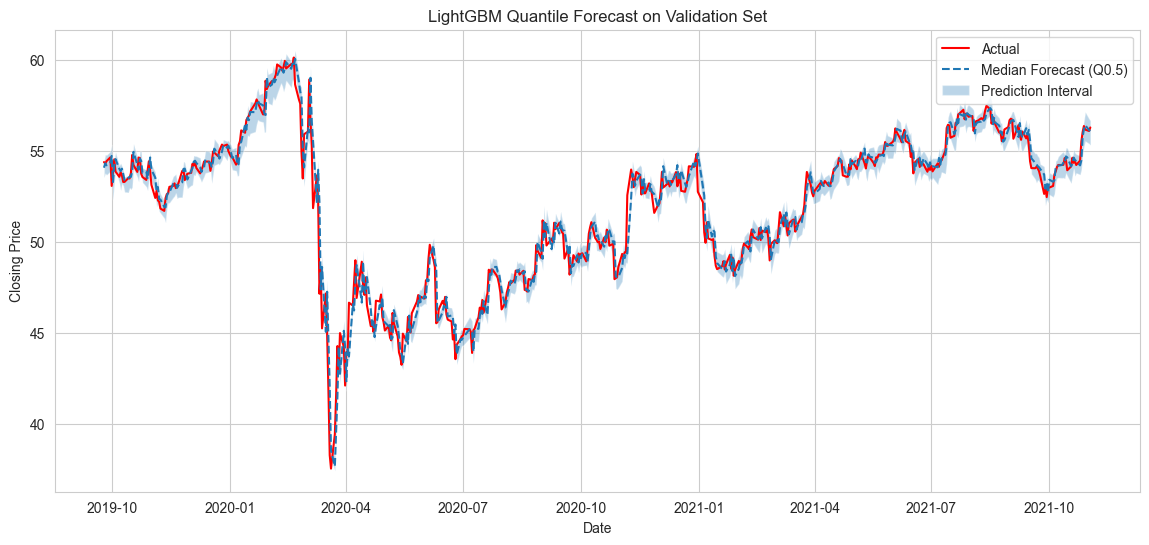

In [78]:
plt.figure(figsize=(14, 6))

plt.plot(lgb_val_df.index, lgb_val_df["actual"], label="Actual", color="red", linewidth=1.5)
plt.plot(lgb_val_df.index, lgb_val_df["q0.5"], label="Median Forecast (Q0.5)", linestyle="--", linewidth=1.5)

plt.fill_between(
    lgb_val_df.index,
    lgb_val_df["q0.025"],
    lgb_val_df["q0.975"],
    alpha=0.3,
    label="Prediction Interval"
)

plt.title("LightGBM Quantile Forecast on Validation Set")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.savefig(FIGURES_DIR / "lightgbm_validation_forecast.png")
plt.show()

In [79]:
# Validation point metrics
y_true_lgb_val = lgb_val_df["actual"]
y_med_lgb_val = lgb_val_df["q0.5"]

mae_lgb_val = mean_absolute_error(y_true_lgb_val, y_med_lgb_val)
mse_lgb_val = mean_squared_error(y_true_lgb_val, y_med_lgb_val)
rmse_lgb_val = np.sqrt(mse_lgb_val)
r2_lgb_val = r2_score(y_true_lgb_val, y_med_lgb_val)

# Validation interval metrics
coverage_lgb_val = ((y_true_lgb_val >= lgb_val_df["q0.025"]) & (y_true_lgb_val <= lgb_val_df["q0.975"])).mean()
interval_width_lgb_val = (lgb_val_df["q0.975"] - lgb_val_df["q0.025"]).mean()

# Validation pinball loss
pinball_q10_lgb_val = mean_pinball_loss(y_true_lgb_val, lgb_val_df["q0.025"], alpha=0.025)
pinball_q50_lgb_val = mean_pinball_loss(y_true_lgb_val, lgb_val_df["q0.5"], alpha=0.5)
pinball_q90_lgb_val = mean_pinball_loss(y_true_lgb_val, lgb_val_df["q0.975"], alpha=0.975)
avg_pinball_lgb_val = np.mean([pinball_q10_lgb_val, pinball_q50_lgb_val, pinball_q90_lgb_val])

# Validation bias and quantile ordering
bias_lgb_val = (y_true_lgb_val - y_med_lgb_val).mean()
violations_lgb_val = ((lgb_val_df["q0.025"] > lgb_val_df["q0.5"]) |
                      (lgb_val_df["q0.5"] > lgb_val_df["q0.975"])).sum()

In [80]:
lgb_validation_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "Coverage",
        "Average Interval Width",
        "Pinball Loss Q0.1",
        "Pinball Loss Q0.5",
        "Pinball Loss Q0.9",
        "Average Pinball Loss",
        "Bias",
        "Quantile Violations"
    ],
    "Value": [
        mae_lgb_val,
        mse_lgb_val,
        rmse_lgb_val,
        r2_lgb_val,
        coverage_lgb_val,
        interval_width_lgb_val,
        pinball_q10_lgb_val,
        pinball_q50_lgb_val,
        pinball_q90_lgb_val,
        avg_pinball_lgb_val,
        bias_lgb_val,
        violations_lgb_val
    ]
})

lgb_validation_metrics

,Metric,Value
0,MAE,0.533650
1,MSE,0.667901
2,RMSE,0.817252
3,R2,0.958416
4,Coverage,0.671053
5,Average Interval Width,1.148705
6,Pinball Loss Q0.1,0.124825
7,Pinball Loss Q0.5,0.266825
8,Pinball Loss Q0.9,0.100029
9,Average Pinball Loss,0.163893


In [81]:
# Combine train and validation sets
X_trainval_safe_lgb = pd.concat([X_train_safe, X_val_safe], axis=0)
y_trainval_safe_lgb = pd.concat([y_train_safe, y_val_safe], axis=0)

# Clip using train+validation only
lower_q_tv_lgb = y_trainval_safe_lgb.quantile(0.01)
upper_q_tv_lgb = y_trainval_safe_lgb.quantile(0.99)
y_trainval_safe_clip_lgb = y_trainval_safe_lgb.clip(lower=lower_q_tv_lgb, upper=upper_q_tv_lgb)

print("Train+Validation shape:", X_trainval_safe_lgb.shape)
print("Test shape:", X_test_safe.shape)

Train+Validation shape: (3014, 32)
Test shape: (532, 32)


In [82]:
lgb_test_models = {}

for q in quantiles_lgb:
    model = lgb.LGBMRegressor(alpha=q, **common_params)
    model.fit(X_trainval_safe_lgb, y_trainval_safe_clip_lgb)
    lgb_test_models[q] = model

print("Final LightGBM models trained on Train + Validation.")

Final LightGBM models trained on Train + Validation.


In [83]:
# Predict returns on test set
lgb_test_pred_ret = {}

for q in quantiles_lgb:
    lgb_test_pred_ret[q] = lgb_test_models[q].predict(X_test_safe)

# Reconstruct next-day prices on test set
current_prices_test_lgb = df_model_safe[CLOSE_COL].iloc[val_end_safe:].values

pred_price_low_test_lgb = current_prices_test_lgb * (1 + lgb_test_pred_ret[0.025])
pred_price_med_test_lgb = current_prices_test_lgb * (1 + lgb_test_pred_ret[0.5])
pred_price_high_test_lgb = current_prices_test_lgb * (1 + lgb_test_pred_ret[0.975])

actual_next_prices_test_lgb = df_model_safe[CLOSE_COL].shift(-1).iloc[val_end_safe:].values

lgb_test_df = pd.DataFrame({
    "actual": actual_next_prices_test_lgb,
    "q0.025": pred_price_low_test_lgb,
    "q0.5": pred_price_med_test_lgb,
    "q0.975": pred_price_high_test_lgb
}, index=df_model_safe.index[val_end_safe:])

lgb_test_df = lgb_test_df.dropna()
lgb_test_df.head()

,actual,q0.025,q0.5,q0.975
Date,,,,
2021-11-03 00:00:00+00:00,56.599998,55.705322,56.372955,57.056658
2021-11-04 00:00:00+00:00,56.840000,55.979021,56.706717,57.344530
2021-11-05 00:00:00+00:00,56.330002,56.240398,56.875948,57.554020
2021-11-08 00:00:00+00:00,56.490002,55.777922,56.394836,57.092909
2021-11-09 00:00:00+00:00,56.720001,55.893033,56.552308,57.240261


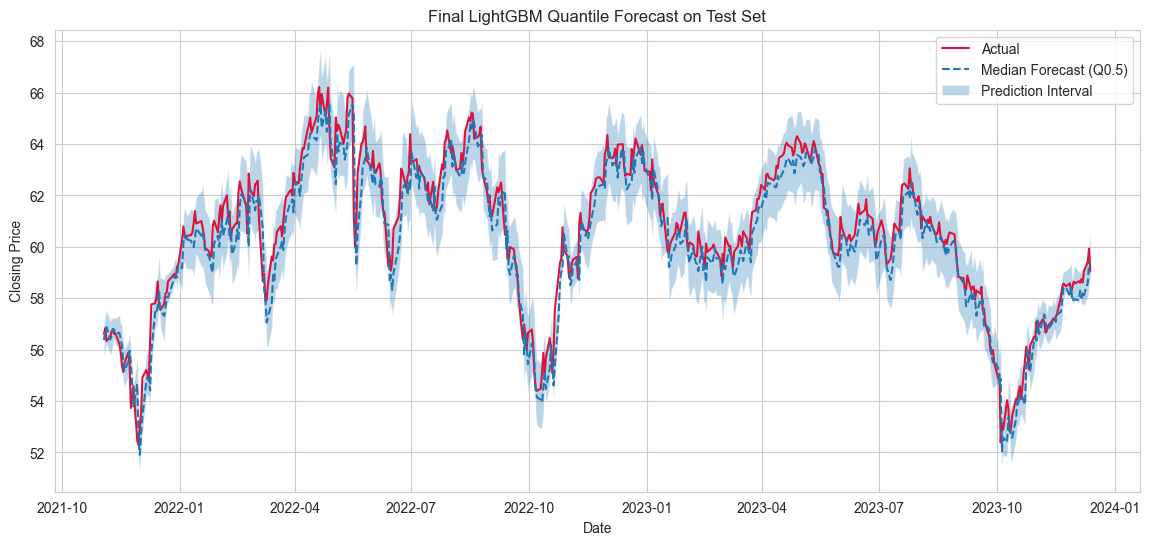

In [84]:
plt.figure(figsize=(14, 6))

plt.plot(lgb_test_df.index, lgb_test_df["actual"], label="Actual", color="crimson", linewidth=1.5)
plt.plot(lgb_test_df.index, lgb_test_df["q0.5"], label="Median Forecast (Q0.5)", linestyle="--", linewidth=1.5)

plt.fill_between(
    lgb_test_df.index,
    lgb_test_df["q0.025"],
    lgb_test_df["q0.975"],
    alpha=0.3,
    label="Prediction Interval"
)

plt.title("Final LightGBM Quantile Forecast on Test Set")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.savefig(FIGURES_DIR / "lightgbm_test_forecast.png")
plt.show()

In [85]:
# Final test metrics
y_true_lgb_test = lgb_test_df["actual"]
y_med_lgb_test = lgb_test_df["q0.5"]

mae_lgb_test = mean_absolute_error(y_true_lgb_test, y_med_lgb_test)
mse_lgb_test = mean_squared_error(y_true_lgb_test, y_med_lgb_test)
rmse_lgb_test = np.sqrt(mse_lgb_test)
r2_lgb_test = r2_score(y_true_lgb_test, y_med_lgb_test)

coverage_lgb_test = ((y_true_lgb_test >= lgb_test_df["q0.025"]) & (y_true_lgb_test <= lgb_test_df["q0.975"])).mean()
interval_width_lgb_test = (lgb_test_df["q0.975"] - lgb_test_df["q0.025"]).mean()

pinball_q10_lgb_test = mean_pinball_loss(y_true_lgb_test, lgb_test_df["q0.025"], alpha=0.025)
pinball_q50_lgb_test = mean_pinball_loss(y_true_lgb_test, lgb_test_df["q0.5"], alpha=0.5)
pinball_q90_lgb_test = mean_pinball_loss(y_true_lgb_test, lgb_test_df["q0.975"], alpha=0.975)
avg_pinball_lgb_test = np.mean([pinball_q10_lgb_test, pinball_q50_lgb_test, pinball_q90_lgb_test])

bias_lgb_test = (y_true_lgb_test - y_med_lgb_test).mean()
violations_lgb_test = ((lgb_test_df["q0.025"] > lgb_test_df["q0.5"]) |
                       (lgb_test_df["q0.5"] > lgb_test_df["q0.975"])).sum()

print("LightGBM Final Test Results")
print(f"MAE: {mae_lgb_test:.4f}")
print(f"MSE: {mse_lgb_test:.4f}")
print(f"RMSE: {rmse_lgb_test:.4f}")
print(f"R2: {r2_lgb_test:.4f}")
print(f"Coverage (Q0.025-Q0.975): {coverage_lgb_test:.4f}")
print(f"Average Interval Width: {interval_width_lgb_test:.4f}")
print(f"Pinball Loss Q0.025: {pinball_q10_lgb_test:.4f}")
print(f"Pinball Loss Q0.5: {pinball_q50_lgb_test:.4f}")
print(f"Pinball Loss Q0.975: {pinball_q90_lgb_test:.4f}")
print(f"Average Pinball Loss: {avg_pinball_lgb_test:.4f}")
print(f"Quantile Ordering Violations: {violations_lgb_test}")
print(f"Median Forecast Bias: {bias_lgb_test:.4f}")

LightGBM Final Test Results
MAE: 0.5964
MSE: 0.6132
RMSE: 0.7831
R2: 0.9261
Coverage (Q0.025-Q0.975): 0.9322
Average Interval Width: 2.5944
Pinball Loss Q0.025: 0.0560
Pinball Loss Q0.5: 0.2982
Pinball Loss Q0.975: 0.0433
Average Pinball Loss: 0.1325
Quantile Ordering Violations: 0
Median Forecast Bias: 0.3910
